# 02 — Simulated Annealing

**Curso:** Inteligencia Artificial — Optimización

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.

## Objetivos

- comprender por qué aceptar temporalmente soluciones peores puede ser útil;
- implementar Simulated Annealing desde cero;
- interpretar el efecto de la temperatura y el calendario de enfriamiento;
- comparar Simulated Annealing con Hill Climbing.

![HillClimbing](https://drive.google.com/uc?export=view&id=13a1dTy2bf9BsgeSZH-cXqJndS1ZKU4DP)



## 1. Un paisaje con varios óptimos

Maximizaremos una función unidimensional multimodal:

$$
f(x)=\sin(3x)+0.35\sin(9x)-0.03(x-2)^2
$$

El algoritmo solo observará valores cercanos al estado actual.

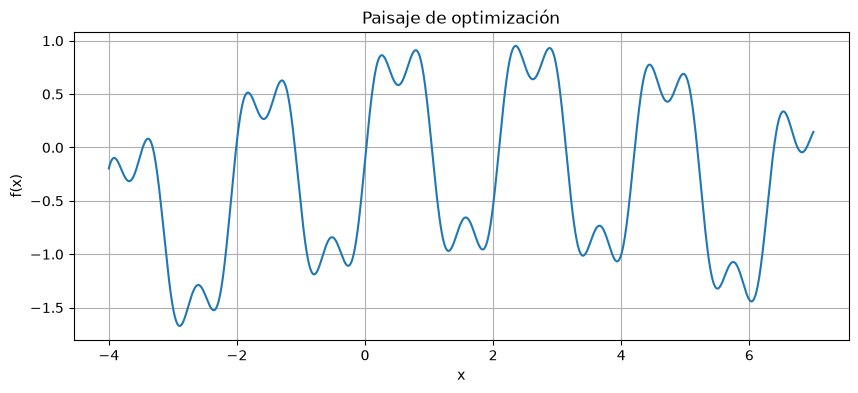

Mejor punto aproximado en la malla: x=2.355, f(x)=0.951


In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 21
random.seed(SEED)
np.random.seed(SEED)


def objective(x):
    return np.sin(3 * x) + 0.35 * np.sin(9 * x) - 0.03 * (x - 2) ** 2

LOWER, UPPER = -4.0, 7.0
xs = np.linspace(LOWER, UPPER, 1500)
ys = objective(xs)

plt.figure(figsize=(10, 4))
plt.plot(xs, ys)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Paisaje de optimización')
plt.grid(True)
plt.show()

best_grid_x = xs[np.argmax(ys)]
print(f'Mejor punto aproximado en la malla: x={best_grid_x:.3f}, f(x)={objective(best_grid_x):.3f}')

## 2. Hill Climbing estocástico como línea base

Propondremos un vecino mediante una perturbación aleatoria pequeña. Hill Climbing acepta el candidato únicamente cuando mejora la función objetivo.

In [2]:
def random_neighbor(x, step_size, rng, lower=LOWER, upper=UPPER):
    candidate = x + rng.uniform(-step_size, step_size)
    return min(upper, max(lower, candidate))


def stochastic_hill_climbing(x0, iterations=300, step_size=0.35, seed=0):
    rng = random.Random(seed)
    x = x0
    trajectory = [(x, float(objective(x)))]

    for _ in range(iterations):
        candidate = random_neighbor(x, step_size, rng)
        if objective(candidate) > objective(x):
            x = candidate
        trajectory.append((x, float(objective(x))))

    return x, trajectory

x0 = -2.5
hill_x, hill_trajectory = stochastic_hill_climbing(x0, seed=SEED)
print(f'Hill Climbing: x={hill_x:.3f}, f(x)={objective(hill_x):.3f}')

Hill Climbing: x=-2.603, f(x)=-1.288


## 3. Regla de aceptación

Sea

$$
\Delta = f(x')-f(x)
$$

Para maximización:

- si $\Delta>0$, aceptamos el candidato;
- si $\Delta\leq 0$, lo aceptamos con probabilidad

$$
P(\text{aceptar})=\exp\left(\frac{\Delta}{T}\right)
$$

Cuando $T$ es alta, el algoritmo explora. Cuando $T$ disminuye, se vuelve más selectivo.

In [3]:
def simulated_annealing(
    x0,
    iterations=800,
    initial_temperature=1.5,
    cooling_rate=0.992,
    step_size=0.45,
    seed=0
):
    rng = random.Random(seed)
    x = x0
    current_value = float(objective(x))
    best_x, best_value = x, current_value
    temperature = initial_temperature
    records = []

    for iteration in range(iterations):
        candidate = random_neighbor(x, step_size, rng)
        candidate_value = float(objective(candidate))
        delta = candidate_value - current_value

        probability = 1.0 if delta > 0 else math.exp(delta / max(temperature, 1e-12))
        accepted = rng.random() < probability

        if accepted:
            x, current_value = candidate, candidate_value

        if current_value > best_value:
            best_x, best_value = x, current_value

        records.append({
            'iteration': iteration,
            'x': x,
            'value': current_value,
            'best_value': best_value,
            'temperature': temperature,
            'delta': delta,
            'probability': probability,
            'accepted': accepted
        })
        temperature *= cooling_rate

    return best_x, best_value, records

sa_x, sa_value, records = simulated_annealing(x0, seed=SEED)
print(f'Simulated Annealing: x={sa_x:.3f}, f(x)={sa_value:.3f}')

Simulated Annealing: x=0.791, f(x)=0.911


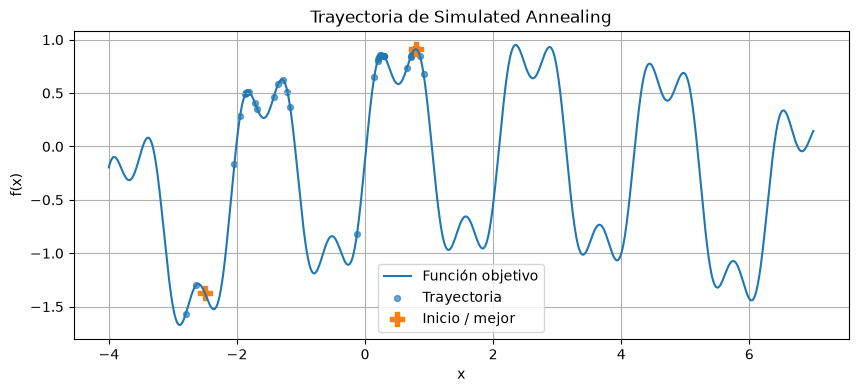

In [4]:
trajectory_x = [r['x'] for r in records]
trajectory_y = [r['value'] for r in records]

plt.figure(figsize=(10, 4))
plt.plot(xs, ys, label='Función objetivo')
plt.scatter(trajectory_x[::12], trajectory_y[::12], s=18, alpha=0.65, label='Trayectoria')
plt.scatter([x0, sa_x], [objective(x0), sa_value], s=100, marker='P', label='Inicio / mejor')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Trayectoria de Simulated Annealing')
plt.legend()
plt.grid(True)
plt.show()

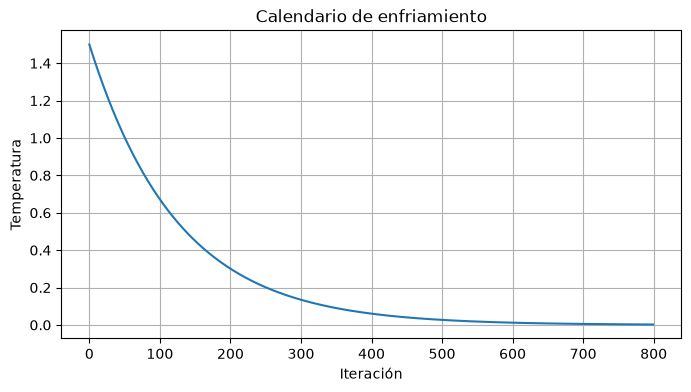

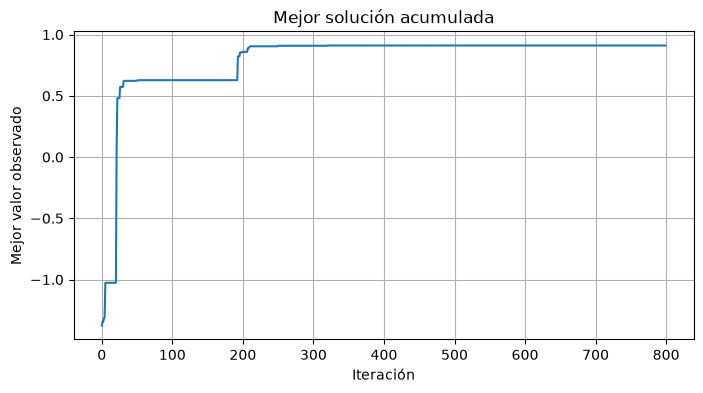

In [5]:
iterations = [r['iteration'] for r in records]
temperatures = [r['temperature'] for r in records]
best_values = [r['best_value'] for r in records]

plt.figure(figsize=(8, 4))
plt.plot(iterations, temperatures)
plt.xlabel('Iteración')
plt.ylabel('Temperatura')
plt.title('Calendario de enfriamiento')
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(iterations, best_values)
plt.xlabel('Iteración')
plt.ylabel('Mejor valor observado')
plt.title('Mejor solución acumulada')
plt.grid(True)
plt.show()

## 4. Comparación estadística

Una sola corrida puede ser engañosa. Compararemos ambos algoritmos usando múltiples semillas y el mismo punto inicial.

Hill Climbing — media: -0.380, mejor: 0.628
Simulated Annealing — media: 0.527, mejor: 0.951


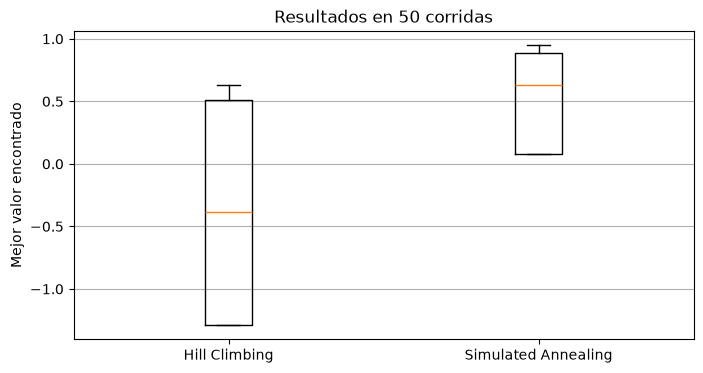

In [6]:
hill_results = []
sa_results = []

for seed in range(50):
    hx, _ = stochastic_hill_climbing(x0, seed=seed)
    sx, sv, _ = simulated_annealing(x0, seed=seed)
    hill_results.append(float(objective(hx)))
    sa_results.append(sv)

print(f'Hill Climbing — media: {np.mean(hill_results):.3f}, mejor: {np.max(hill_results):.3f}')
print(f'Simulated Annealing — media: {np.mean(sa_results):.3f}, mejor: {np.max(sa_results):.3f}')

plt.figure(figsize=(8, 4))
plt.boxplot([hill_results, sa_results], tick_labels=['Hill Climbing', 'Simulated Annealing'])
plt.ylabel('Mejor valor encontrado')
plt.title('Resultados en 50 corridas')
plt.grid(True, axis='y')
plt.show()

## Actividades

### Actividad 1 — Temperatura inicial

Evalúa $T_0\in\{0.01,0.1,0.5,1,3,10\}$. Para cada valor realiza 30 corridas y registra:

- valor medio de la mejor solución;
- desviación estándar;
- porcentaje de corridas que alcanzan un valor cercano al mejor global aproximado.

In [10]:
# Complete the experiment for different initial temperatures
temperatures_to_test = [0.01, 0.1, 0.5, 1, 3, 10]
experiment = []

# Define threshold for "close to global best"
global_best_threshold = best_grid_x - 0.1  # values within 0.1 of the best grid approximation

for temperature in temperatures_to_test:
    values = []
    for seed in range(30):
        _, value, _ = simulated_annealing(x0, iterations=30, initial_temperature=temperature, seed=seed)
        values.append(value)
    
    mean_value = np.mean(values)
    std_value = np.std(values)
    close_to_best = sum(1 for v in values if v >= objective(best_grid_x) - 0.1) / len(values) * 100
    
    experiment.append({
        'temperature': temperature,
        'mean': mean_value,
        'std': std_value,
        'percent_close': close_to_best
    })

# Display results
print("Initial Temperature Analysis:")
print(f"{'T0':<8} {'Mean':<12} {'Std Dev':<12} {'% Close to Best':<15}")
print("-" * 50)
for result in experiment:
    print(f"{result['temperature']:<8.2f} {result['mean']:<12.4f} {result['std']:<12.4f} {result['percent_close']:<15.1f}%")

Initial Temperature Analysis:
T0       Mean         Std Dev      % Close to Best
--------------------------------------------------
0.01     0.4139       0.3690       0.0            %
0.10     0.4807       0.2223       0.0            %
0.50     0.3924       0.2809       3.3            %
1.00     0.4032       0.2755       3.3            %
3.00     0.3737       0.2722       6.7            %
10.00    0.3807       0.2825       6.7            %


### Actividad 2 — Enfriamiento

Compara diferentes valores de $\alpha$ en

$$
T_{t+1}=\alpha T_t
$$

Explica por qué un enfriamiento demasiado rápido puede convertir el algoritmo en Hill Climbing.

alpha    mean         std          % close   
---------------------------------------------
0.900    0.3809       0.2827       3.3       
0.940    0.3912       0.2704       0.0       
0.970    0.4005       0.2831       3.3       
0.990    0.4867       0.3281       23.3      
0.995    0.5713       0.3218       30.0      
0.999    0.7226       0.2612       53.3      


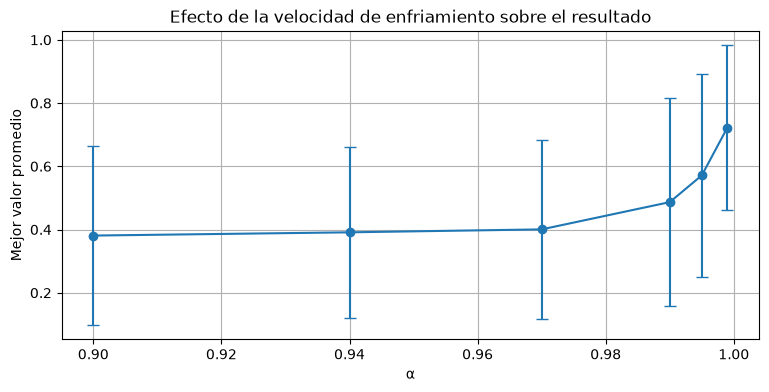

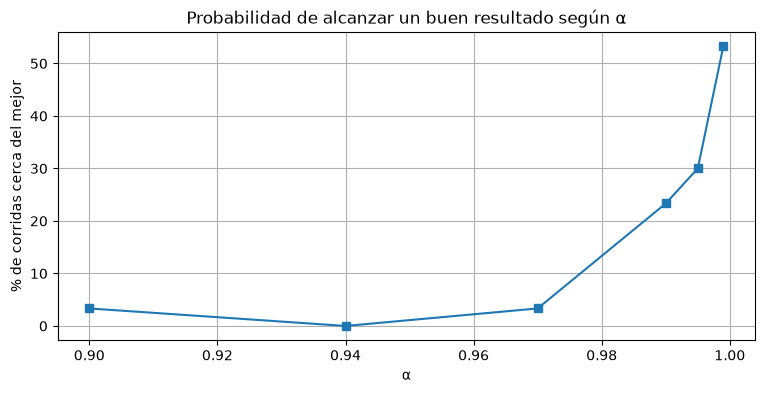

In [11]:
cooling_alphas = [0.90, 0.94, 0.97, 0.99, 0.995, 0.999]
alpha_experiment = []

threshold_value = objective(best_grid_x) - 0.1

for alpha in cooling_alphas:
    values = []
    for seed in range(30):
        _, value, _ = simulated_annealing(
            x0,
            iterations=300,
            initial_temperature=1.5,
            cooling_rate=alpha,
            seed=seed
        )
        values.append(value)

    alpha_experiment.append({
        'alpha': alpha,
        'mean': np.mean(values),
        'std': np.std(values),
        'percent_close': sum(v >= threshold_value for v in values) / len(values) * 100
    })

print(f"{'alpha':<8} {'mean':<12} {'std':<12} {'% close':<10}")
print("-" * 45)
for result in alpha_experiment:
    print(f"{result['alpha']:<8.3f} {result['mean']:<12.4f} {result['std']:<12.4f} {result['percent_close']:<10.1f}")

plt.figure(figsize=(9, 4))
plt.errorbar(
    [r['alpha'] for r in alpha_experiment],
    [r['mean'] for r in alpha_experiment],
    yerr=[r['std'] for r in alpha_experiment],
    marker='o',
    capsize=4
)
plt.xlabel('α')
plt.ylabel('Mejor valor promedio')
plt.title('Efecto de la velocidad de enfriamiento sobre el resultado')
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(
    [r['alpha'] for r in alpha_experiment],
    [r['percent_close'] for r in alpha_experiment],
    marker='s'
)
plt.xlabel('α')
plt.ylabel('% de corridas cerca del mejor')
plt.title('Probabilidad de alcanzar un buen resultado según α')
plt.grid(True)
plt.show()

# Explicación:
# Un enfriamiento demasiado rápido (α pequeño) hace que la temperatura se reduzca
# rápidamente. Entonces la probabilidad de aceptar peores soluciones,
# exp(delta / T), cae casi a cero y el algoritmo solo acepta mejoras,
# comportándose de forma similar a Hill Climbing.

### Actividad 3 — Problema discreto

Adapta Simulated Annealing al problema de hospitales del notebook anterior. Recuerda que, al minimizar, puedes definir

$$
\Delta = C(	actual)-C(candidato)
$$

para conservar la misma lógica de aceptación usada en este notebook.

Mejor solución encontrada: [2, 3, 9, 16, 17]
Costo asociado: 220.8326863819624


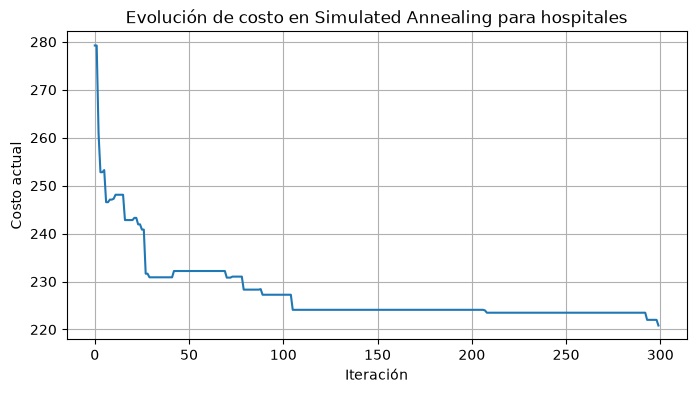

: 

In [ ]:
def cost_hospital_solution(solution, demand_points, facility_points):
    selected = facility_points[np.array(solution)]
    distances = np.linalg.norm(demand_points[:, None, :] - selected[None, :, :], axis=2)
    return float(np.min(distances, axis=1).sum())


def random_neighbor_hospital(solution, n_sites, rng):
    candidate = solution.copy()
    chosen = rng.randrange(len(candidate))
    available = list(set(range(n_sites)) - set(candidate))
    if available:
        candidate[chosen] = rng.choice(available)
        candidate = sorted(candidate)
    return candidate


def simulated_annealing_hospitals(
    initial_solution,
    facility_points,
    demand_points,
    iterations=400,
    initial_temperature=1.5,
    cooling_rate=0.99,
    seed=0
):
    rng = random.Random(seed)
    current_solution = sorted(initial_solution)
    current_cost = cost_hospital_solution(current_solution, demand_points, facility_points)
    best_solution, best_cost = current_solution.copy(), current_cost
    temperature = initial_temperature
    records = []

    for iteration in range(iterations):
        candidate_solution = random_neighbor_hospital(current_solution, len(facility_points), rng)
        candidate_cost = cost_hospital_solution(candidate_solution, demand_points, facility_points)
        delta = current_cost - candidate_cost

        probability = 1.0 if delta > 0 else math.exp(delta / max(temperature, 1e-12))
        accepted = rng.random() < probability

        if accepted:
            current_solution, current_cost = candidate_solution, candidate_cost

        if current_cost < best_cost:
            best_solution, best_cost = current_solution.copy(), current_cost

        records.append({
            'iteration': iteration,
            'current_solution': current_solution.copy(),
            'current_cost': current_cost,
            'best_cost': best_cost,
            'temperature': temperature,
            'delta': delta,
            'probability': probability,
            'accepted': accepted
        })

        temperature *= cooling_rate

    return best_solution, best_cost, records


# Ejemplo de problema de hospitales
n_sites = 25
n_hospitals = 5
n_demand = 120

facility_points = np.random.RandomState(SEED).uniform(0, 10, (n_sites, 2))
demand_points = np.random.RandomState(SEED + 1).uniform(0, 10, (n_demand, 2))
initial_solution = sorted(random.Random(SEED).sample(range(n_sites), k=n_hospitals))

best_solution, best_cost, hospital_records = simulated_annealing_hospitals(
    initial_solution,
    facility_points,
    demand_points,
    iterations=300,
    initial_temperature=1.5,
    cooling_rate=0.98,
    seed=SEED
)

print('Mejor solución encontrada:', best_solution)
print('Costo asociado:', best_cost)

plt.figure(figsize=(8, 4))
plt.plot([r['iteration'] for r in hospital_records], [r['current_cost'] for r in hospital_records])
plt.xlabel('Iteración')
plt.ylabel('Costo actual')
plt.title('Evolución de costo en Simulated Annealing para hospitales')
plt.grid(True)
plt.show()

## Preguntas de cierre

**1. ¿Por qué Simulated Annealing conserva la mejor solución observada, además de la solución actual?**
 Porque el algoritmo explora, puede moverse a soluciones peores para escapar de óptimos locales. Si no guardara la mejor solución observada, podría perder la mejor configuración encontrada durante la búsqueda. Por eso se mantiene tanto la solución actual como la mejor encontrada hasta el momento.


**2. ¿Qué ocurre si la temperatura nunca disminuye?**
Si la temperatura nunca disminuye, el algoritmo no “enfría” y sigue aceptando cambios peores con la misma probabilidad. Eso mantiene mucha exploración y puede impedir la convergencia; el proceso se comporta más como un muestreo estocástico con aceptación Metropolis que como una búsqueda que se va volviendo más selectiva.


**3. ¿Qué ocurre si la temperatura inicial es prácticamente cero?**
No hay forma derantizar que va a converger el algoritmo

 Con temperatura inicial prácticamente cero, la probabilidad de aceptar peores soluciones es casi cero. En ese caso el algoritmo se comporta casi igual que Hill Climbing: solo acepta mejoras y tiene pocas posibilidades de escapar de óptimos locales.



**4. ¿Simulated Annealing garantiza el óptimo global con un número finito de iteraciones?**
 No. Con un número finito de iteraciones no hay garantía de encontrar el óptimo global en general. Simulated Annealing aumenta la probabilidad de hallar buenas soluciones y, en el límite de iteraciones infinitas y un enfriamiento muy lento, tiene propiedades teóricas de convergencia, pero con tiempo finito sigue siendo una heurística sin garantía absoluta.